In [3]:
%pip install python-chess

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import chess.pgn
import chess
import pandas as pd
import numpy as np
from collections import Counter

In [5]:
def extract_features(game):
    board = game.board()

    white_moves = []
    black_moves = []

    white_captures = 0
    black_captures = 0
    white_checks   = 0
    black_checks   = 0
    white_castled  = False
    black_castled  = False
    white_promotions = 0
    black_promotions = 0

    # piece type counts: pawn=1 N=2 B=3 R=4 Q=5 K=6
    white_piece_diversity = set()
    black_piece_diversity = set()

    move_number = 0
    for move in game.mainline_moves():
        san = board.san(move)
        is_white = board.turn  # True = white's turn

        piece = board.piece_at(move.from_square)
        piece_type = piece.piece_type if piece else 0

        if is_white:
            white_moves.append(san)
            white_piece_diversity.add(piece_type)
            if board.is_capture(move):
                white_captures += 1
            if move.promotion:
                white_promotions += 1
            if san.endswith("+") or san.endswith("#"):
                white_checks += 1
            if san in ("O-O", "O-O-O"):
                white_castled = True
        else:
            black_moves.append(san)
            black_piece_diversity.add(piece_type)
            if board.is_capture(move):
                black_captures += 1
            if move.promotion:
                black_promotions += 1
            if san.endswith("+") or san.endswith("#"):
                black_checks += 1
            if san in ("O-O", "O-O-O"):
                black_castled = True

        board.push(move)
        move_number += 1

    total_moves = move_number
    white_count = len(white_moves)
    black_count = len(black_moves)

    return {
        # game-level
        "total_moves":          total_moves,
        "result":               game.headers.get("Result", "*"),

        # white features
        "white_move_count":     white_count,
        "white_captures":       white_captures,
        "white_checks":         white_checks,
        "white_castled":        int(white_castled),
        "white_promotions":     white_promotions,
        "white_piece_diversity":len(white_piece_diversity),
        "white_capture_rate":   white_captures / white_count if white_count else 0,
        "white_check_rate":     white_checks   / white_count if white_count else 0,

        # black features
        "black_move_count":     black_count,
        "black_captures":       black_captures,
        "black_checks":         black_checks,
        "black_castled":        int(black_castled),
        "black_promotions":     black_promotions,
        "black_piece_diversity":len(black_piece_diversity),
        "black_capture_rate":   black_captures / black_count if black_count else 0,
        "black_check_rate":     black_checks   / black_count if black_count else 0,

        # raw elos (targets)
        "WhiteElo":             int(game.headers.get("WhiteElo", 0)),
        "BlackElo":             int(game.headers.get("BlackElo", 0)),
    }

In [6]:
pgn_path = r"C:\Users\Admin\source\Phyton\ARJK\data.pgn"

rows = []
with open(pgn_path, encoding="utf-8") as pgn:
    while True:
        game = chess.pgn.read_game(pgn)
        if game is None:
            break
        rows.append(extract_features(game))

df = pd.DataFrame(rows)
print(f"Total games loaded: {len(df)}")
print(df.head(5))

Total games loaded: 50000
   total_moves   result  white_move_count  white_captures  white_checks  \
0           38  1/2-1/2                19               4             1   
1           13  1/2-1/2                 7               1             0   
2          106      0-1                53              11             4   
3           77      1-0                39               8             4   
4           49      1-0                25               8             4   

   white_castled  white_promotions  white_piece_diversity  white_capture_rate  \
0              1                 0                      6            0.210526   
1              1                 0                      4            0.142857   
2              1                 0                      6            0.207547   
3              0                 0                      6            0.205128   
4              1                 0                      5            0.320000   

   white_check_rate  black_move_coun

In [7]:
# Drop games with missing Elo
df = df[(df["WhiteElo"] > 0) & (df["BlackElo"] > 0)].copy()

# Encode result as a number
result_map = {"1-0": 1, "0-1": 0, "1/2-1/2": 0.5}
df["result_encoded"] = df["result"].map(result_map).fillna(0.5)

df.drop(columns=["result"], inplace=True)

In [8]:
from sklearn.model_selection import train_test_split

# White model uses white's own move features
white_features = [
    "total_moves", "result_encoded",
    "white_move_count", "white_captures", "white_checks",
    "white_castled", "white_promotions", "white_piece_diversity",
    "white_capture_rate", "white_check_rate",
    # opponent context
    "black_move_count", "black_captures", "black_checks",
    "black_castled", "black_piece_diversity",
]

# Black model uses black's own move features
black_features = [
    "total_moves", "result_encoded",
    "black_move_count", "black_captures", "black_checks",
    "black_castled", "black_promotions", "black_piece_diversity",
    "black_capture_rate", "black_check_rate",
    # opponent context
    "white_move_count", "white_captures", "white_checks",
    "white_castled", "white_piece_diversity",
]

X_white = df[white_features]
X_black = df[black_features]
y_white = df["WhiteElo"]
y_black = df["BlackElo"]

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42
)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_black, y_black, test_size=0.2, random_state=42
)

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

model_white = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

model_black = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

model_white.fit(Xw_train, yw_train)
model_black.fit(Xb_train, yb_train)



,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [10]:
from sklearn.metrics import mean_absolute_error, r2_score

yw_pred = model_white.predict(Xw_test)
yb_pred = model_black.predict(Xb_test)

print("=== White Elo ===")
print(f"  MAE:  {mean_absolute_error(yw_test, yw_pred):.1f}")
print(f"  RMSE: {np.sqrt(np.mean((yw_test - yw_pred)**2)):.1f}")
print(f"  R²:   {r2_score(yw_test, yw_pred):.4f}")

print("\n=== Black Elo ===")
print(f"  MAE:  {mean_absolute_error(yb_test, yb_pred):.1f}")
print(f"  RMSE: {np.sqrt(np.mean((yb_test - yb_pred)**2)):.1f}")
print(f"  R²:   {r2_score(yb_test, yb_pred):.4f}")

=== White Elo ===
  MAE:  204.4
  RMSE: 255.3
  R²:   0.1065

=== Black Elo ===
  MAE:  207.9
  RMSE: 259.4
  R²:   0.0733


In [11]:
print("White — Predicted:", yw_pred[:5].round(0))
print("White — Actual:   ", yw_test.values[:5])

print("\nBlack — Predicted:", yb_pred[:5].round(0))
print("Black — Actual:   ", yb_test.values[:5])

White — Predicted: [2152. 2042. 2307. 2168. 2139.]
White — Actual:    [2419 2249 2642 1877 2239]

Black — Predicted: [2314. 2238. 2298. 2235. 2264.]
Black — Actual:    [2484 2272 2687 2037 2016]


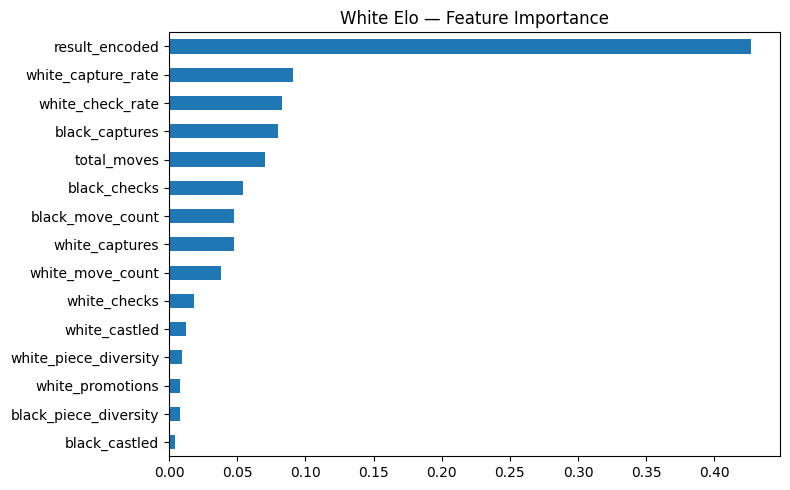

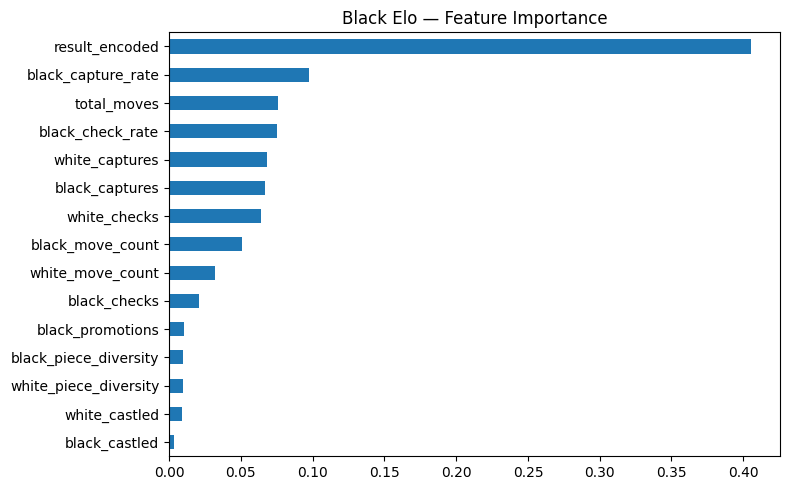

In [12]:
import matplotlib.pyplot as plt

for label, model, features in [
    ("White", model_white, white_features),
    ("Black", model_black, black_features),
]:
    importance = pd.Series(model.feature_importances_, index=features)
    importance.sort_values().plot(kind="barh", figsize=(8, 5), title=f"{label} Elo — Feature Importance")
    plt.tight_layout()
    plt.show()